In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
from google.colab import files
import io

In [ ]:
uploaded = files.upload() #using google colab to upload the csv file

Saving negative_samples_human_AI_reasoning_compare.csv to negative_samples_human_AI_reasoning_compare.csv


In [ ]:
#files can be found in data/temp/positive_samples.csv and data/temp/negative_samples.csv

df_pos = pd.read_csv('/content/positive_samples_human_AI_reasoning_compare.csv')
df_neg = pd.read_csv('/content/negative_samples_human_AI_reasoning_compare.csv')

In [ ]:
#Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
#gemini generate this function to calculate the cosine similarity between two columns of text in a dataframe using the sentence transformer model. 


def get_sim(row, col_a, col_b):
    # Ensure inputs are strings and not empty
    text_a = str(row[col_a]) if pd.notnull(row[col_a]) else ""
    text_b = str(row[col_b]) if pd.notnull(row[col_b]) else ""

    if not text_a or not text_b:
        return 0.0

    emb_a = model.encode(text_a, convert_to_tensor=True)
    emb_b = model.encode(text_b, convert_to_tensor=True)
    return util.cos_sim(emb_a, emb_b).item()

In [ ]:
# Calculate Similarity for Reasoning for positive samples
df_pos['reasoning_sim'] = df_pos.apply(lambda r: get_sim(r, 'r1_reasoning', 'human_reasoning'), axis=1)


# Visualization: Side-by-Side Comparison
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

/tmp/ipykernel_1520/1902843723.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Similarity', data=plot_data, palette="Set2", width=0.5)


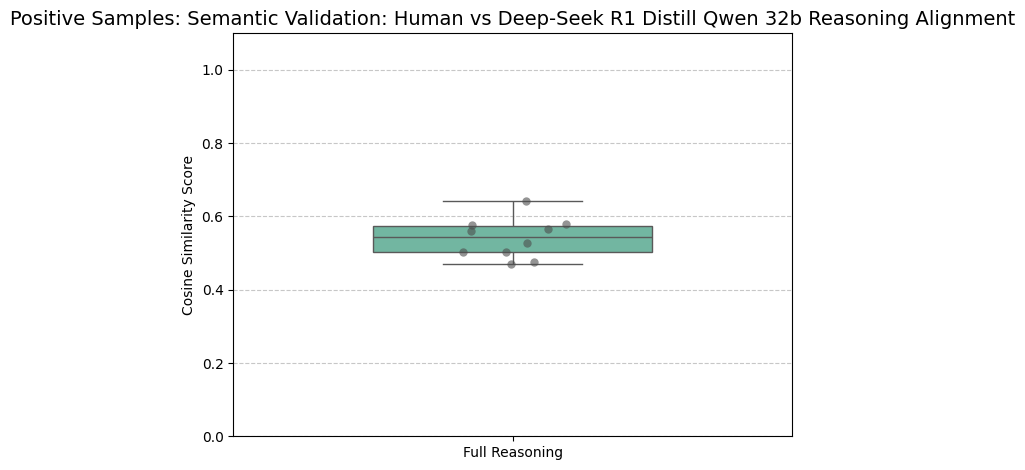

Mean Reasoning Sim: 0.540


In [ ]:

#gemini generate this code to create a boxplot with a stripplot overlay to visualize the distribution of cosine similarity scores for the reasoning alignment between human and Deep-Seek R1 Distill Qwen 32b for the positive samples. We prepare the data by melting the relevant columns into a long format suitable for seaborn, and we customize the plot with titles, labels, and gridlines for better readability.
# Prepare data for plotting
plot_data = df_pos[['reasoning_sim']].melt(var_name='Type', value_name='Similarity')
plot_data['Type'] = plot_data['Type'].replace({'reasoning_sim': 'Full Reasoning'})

sns.boxplot(x='Type', y='Similarity', data=plot_data, palette="Set2", width=0.5)
sns.stripplot(x='Type', y='Similarity', data=plot_data, color=".3", size=6, jitter=True, alpha=0.6)

plt.title("Positive Samples: Semantic Validation: Human vs Deep-Seek R1 Distill Qwen 32b Reasoning Alignment", fontsize=14)
plt.ylabel("Cosine Similarity Score")
plt.xlabel("")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Mean Reasoning Sim: {df_pos['reasoning_sim'].mean():.3f}")

In [ ]:
# Calculate Similarity for Reasoning for negative samples
df_neg['reasoning_sim'] = df_neg.apply(lambda r: get_sim(r, 'r1_reasoning', 'human_reasoning'), axis=1)


# 3. Visualization: Side-by-Side Comparison
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

/tmp/ipykernel_1520/3851397156.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Similarity', data=plot_data, palette="Set1", width=0.5)


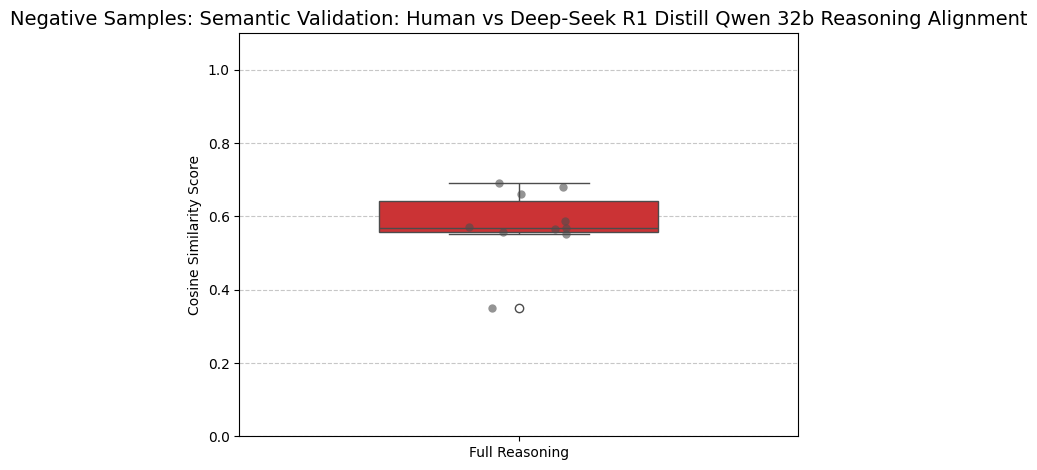

Mean Reasoning Sim: 0.579


In [ ]:
# Prepare data for plotting
plot_data = df_neg[['reasoning_sim']].melt(var_name='Type', value_name='Similarity')
plot_data['Type'] = plot_data['Type'].replace({'reasoning_sim': 'Full Reasoning'})

sns.boxplot(x='Type', y='Similarity', data=plot_data, palette="Set1", width=0.5)
sns.stripplot(x='Type', y='Similarity', data=plot_data, color=".3", size=6, jitter=True, alpha=0.6)

plt.title("Negative Samples: Semantic Validation: Human vs Deep-Seek R1 Distill Qwen 32b Reasoning Alignment", fontsize=14)
plt.ylabel("Cosine Similarity Score")
plt.xlabel("")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Mean Reasoning Sim: {df_neg['reasoning_sim'].mean():.3f}")